# 01. FLIR Termal Veri Seti Keşifsel Veri Analizi (EDA)

Bu notebook, Hugging Face FLIR veri kümesinden çıkarılan kara aracı (`car`) ve piyade/personel (`person`) termal hedeflerini istatistiksel ve morfolojik olarak inceler. Amaç; sınıf dengesizliklerini, hedef boyut dağılımlarını ve termal ısı imzalarını analiz ederek model eğitim stratejimizi ve ön işleme adımlarımızı optimize etmektir.

In [9]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

DATA_DIR = "../dataset/raw/train"
classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]

records = []

for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                arr = np.array(img.convert('L'))
                records.append({
                    'class': cls,
                    'width': w,
                    'height': h,
                    'aspect_ratio': round(w / h, 2) if h > 0 else 0,
                    'mean_intensity': arr.mean(),
                    'std_intensity': arr.std()
                })
        except Exception:
            pass

df = pd.DataFrame(records)
print(f"Toplam Eğitim Görseli Sayısı: {len(df)}")
df.head()

Toplam Eğitim Görseli Sayısı: 35862


,class,width,height,aspect_ratio,mean_intensity,std_intensity
0,car,23,26,0.88,152.814381,60.435465
1,car,96,90,1.07,163.602894,40.006476
2,car,26,32,0.81,153.248798,41.770284
3,car,31,42,0.74,156.159754,39.404893
4,car,36,30,1.20,179.337963,31.669498


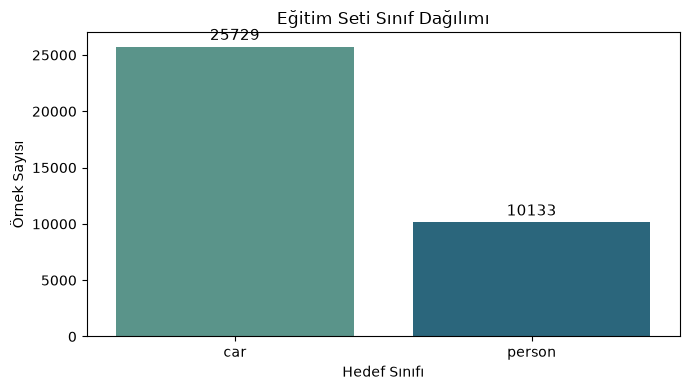

--- Sınıf Yüzdeleri ---
class
car       71.74 %
person    28.26 %
Name: proportion, dtype: str


In [10]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='class', hue='class', palette='crest', legend=False)
plt.title('Eğitim Seti Sınıf Dağılımı')
plt.xlabel('Hedef Sınıfı')
plt.ylabel('Örnek Sayısı')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

print("--- Sınıf Yüzdeleri ---")
print((df['class'].value_counts(normalize=True) * 100).round(2).astype(str) + ' %')

### 1. Sınıf Denge Değerlendirmesi
Eğitim veri setinde toplam 35.862 görsel bulunmakta olup veri kümesinin yaklaşık %71.7'sini araçlar (`car`: 25.729), %28.3'ünü ise personel (`person`: 10.133) oluşturmaktadır. 

Bu durum hafif düzeyde bir sınıf dengesizliğine (class imbalance) işaret eder. Modelin araç sınıfına aşırı yatkınlık (bias) geliştirmesini engellemek için eğitim aşamasında loss fonksiyonuna ağırlık katsayısı eklenmesi (`Weighted CrossEntropyLoss`) veya doğrulama metriklerinde yalnızca Accuracy yerine **F1-Score / Macro Precision-Recall** değerlerinin dikkate alınması kritik öneme sahiptir.

C:\Users\sibel\AppData\Local\Temp\ipykernel_29164\2866769071.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y='aspect_ratio', ax=axes[1], palette='crest')


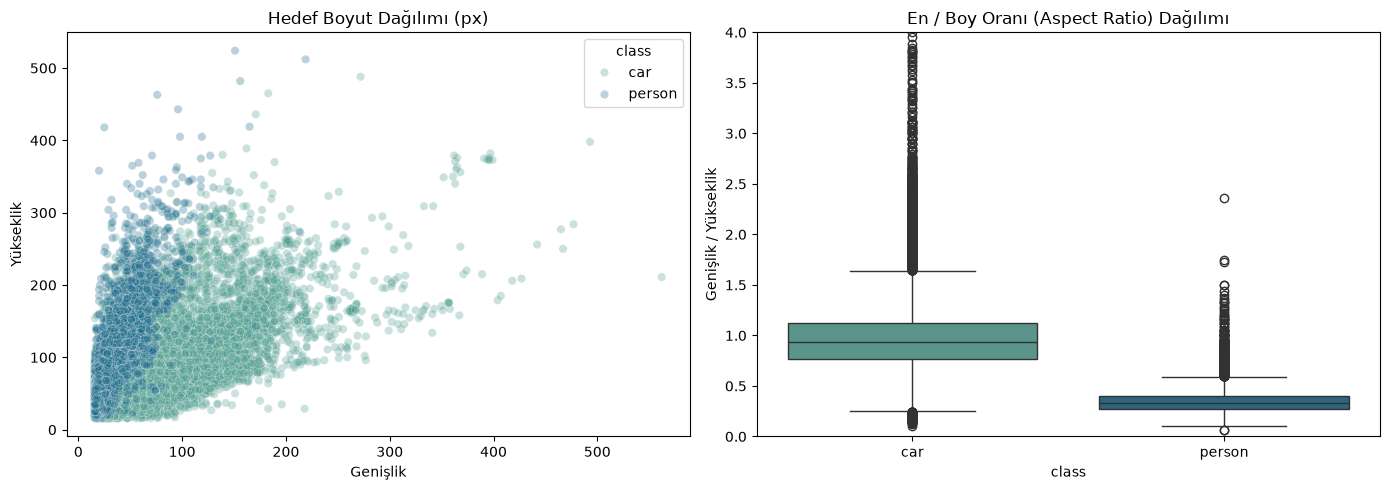

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Genişlik vs Yükseklik
sns.scatterplot(data=df, x='width', y='height', hue='class', alpha=0.3, ax=axes[0], palette='crest')
axes[0].set_title('Hedef Boyut Dağılımı (px)')
axes[0].set_xlabel('Genişlik')
axes[0].set_ylabel('Yükseklik')

# 2. En-Boy Oranı Dağılımı
sns.boxplot(data=df, x='class', y='aspect_ratio', ax=axes[1], palette='crest')
axes[1].set_title('En / Boy Oranı (Aspect Ratio) Dağılımı')
axes[1].set_ylabel('Genişlik / Yükseklik')
axes[1].set_ylim(0, 4)

plt.tight_layout()
plt.show()

### 2. Hedef Geometrisi ve Yeniden Boyutlandırma Analizi
Grafikler incelendiğinde; piyade/personel (`person`) hedeflerinin dikey yönelimli (düşük en-boy oranı, $W/H < 0.6$), araç (`car`) hedeflerinin ise belirgin şekilde yatay yönelimli ($W/H > 1.2$) olduğu görülmektedir. 

CNN modellerinin standart giriş boyutu olan $224 \times 224$ kare tensör formatına doğrudan dönüştürme yapıldığında hedeflerde morfolojik uzama/basılma meydana gelecektir. Ancak derin öğrenme katmanları bu geometrik bozulmalara karşı toleranslıdır. Aşırı deformasyonu önlemek adına eğitim esnasında rastgele kırpma yerine kontrollü yeniden boyutlandırma ve hafif geometrik rotasyonlar uygulanacaktır.

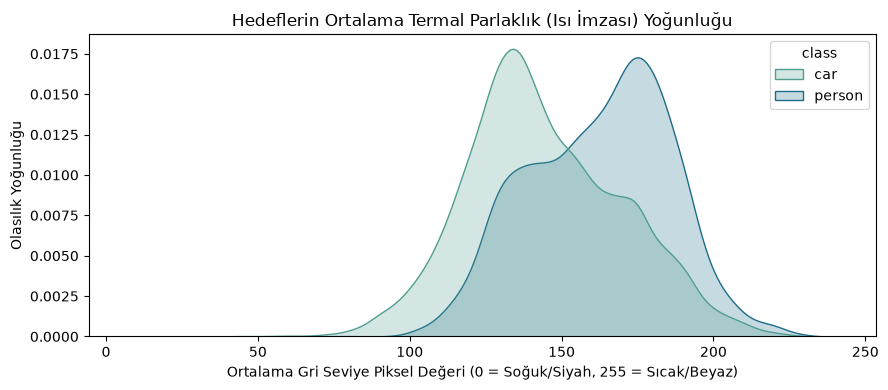

In [13]:
plt.figure(figsize=(9, 4))
sns.kdeplot(data=df, x='mean_intensity', hue='class', fill=True, common_norm=False, palette='crest')
plt.title('Hedeflerin Ortalama Termal Parlaklık (Isı İmzası) Yoğunluğu')
plt.xlabel('Ortalama Gri Seviye Piksel Değeri (0 = Soğuk/Siyah, 255 = Sıcak/Beyaz)')
plt.ylabel('Olasılık Yoğunluğu')
plt.tight_layout()
plt.show()

### 3. Termal Isı İmzası (Thermal Signature) Değerlendirmesi
Piksel yoğunluk eğrileri incelendiğinde araç sınıfının tepe noktasının insan sınıfına göre daha sağda (daha yüksek gri tonu / parlaklık) olduğu gözlemlenmektedir. Bunun temel fiziksel nedeni; araçların motor bloğu, egzoz hattı ve tekerlek sürtünmelerinden kaynaklanan yüksek termal emisyon yaymasıdır. 

Personel sınıfında ise termal yayılım insan vücut sıcaklığı ile sınırlı olup arka planla kontrastı araçlara göre daha düşüktür. Bu ayrım, modelin konvolüsyon katmanlarında ısı geçiş gradyanlarını güçlü bir öznitelik olarak kullanabileceğini doğrulamaktadır.

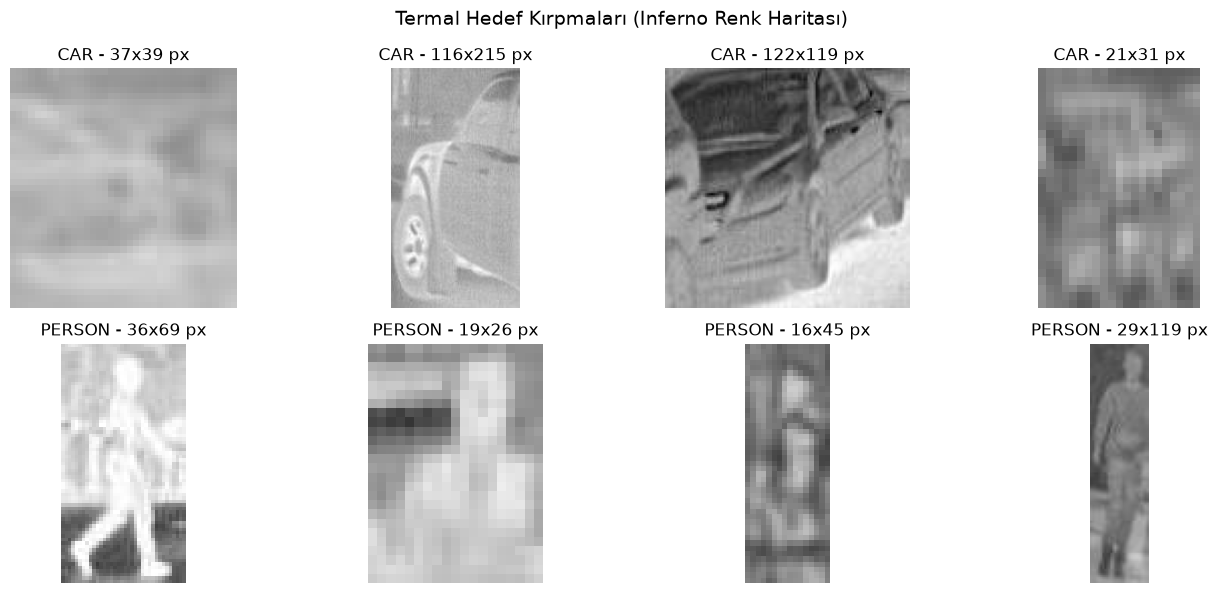

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for row_idx, cls in enumerate(['car', 'person']):
    cls_path = os.path.join(DATA_DIR, cls)
    sample_files = random.sample(os.listdir(cls_path), 4)
    for col_idx, file_name in enumerate(sample_files):
        img = Image.open(os.path.join(cls_path, file_name))
        axes[row_idx, col_idx].imshow(img, cmap='inferno')
        axes[row_idx, col_idx].set_title(f"{cls.upper()} - {img.size[0]}x{img.size[1]} px")
        axes[row_idx, col_idx].axis('off')

plt.suptitle("Termal Hedef Kırpmaları (Inferno Renk Haritası)", fontsize=14)
plt.tight_layout()
plt.show()

### 4. EDA Genel Çıkarımları ve Pipeline Kararları
* **Veri Kalitesi:** Otomatik kırpma filtresi ($>15$ px) sayesinde gürültüsüz, doğrudan hedefe odaklı bir veri havuzu elde edilmiştir.
* **Normalizasyon:** Termal veriler tek kanallı gri seviye olsa da transfer öğrenme omurgalarımızın (ResNet, MobileNet vb.) ImageNet ağırlıklarına uyumu için tensörler 3 kanala çoğaltılacak ve standart ImageNet ortalama/standart sapma değerleriyle normalize edilecektir.
* **Veri Artırımı (Augmentation):** Termal verilerde renk bilgisi bulunmadığından renk değişimleri yerine sadece rastgele yatay çevirme (`RandomHorizontalFlip`) ve hafif açısal rotasyon (`RandomRotation`) uygulanacaktır.